In [4]:
# Load packages

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import (roc_auc_score, 
                             roc_curve,
                             confusion_matrix,
                             average_precision_score,
                             log_loss,
                             brier_score_loss,
                             precision_score,
                             recall_score,
                             f1_score,
                             accuracy_score
                             )

import matplotlib.pyplot as plt

from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib
import json

In [ ]:
# Helper functions to run logistic regression and evaluate performance

def build_model_form(target, features):
    return f"{target} = " + " + ".join(features)


def add_significance_stars(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    elif p_value < 0.10:
        return "."
    else:
        return ""


def ks_statistic(y_true, y_score):
    temp = pd.DataFrame({
        "y_true": y_true,
        "y_score": y_score
    }).sort_values("y_score", ascending=False)
    temp["good"] = (temp["y_true"] == 0).astype(int)
    temp["bad"] = (temp["y_true"] == 1).astype(int)
    temp["cum_good"] = temp["good"].cumsum() / temp["good"].sum()
    temp["cum_bad"] = temp["bad"].cumsum() / temp["bad"].sum()
    return (temp["cum_bad"] - temp["cum_good"]).abs().max()


def calculate_classification_diagnostics(
    y_train,
    p_train,
    y_val,
    p_val,
    threshold=0.50
):
    def _metrics(y_true, y_score, dataset_name):
        y_pred = (y_score >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        return {
            "dataset": dataset_name,
            "threshold": threshold,
            "auc": roc_auc_score(y_true, y_score),
            "gini": 2 * roc_auc_score(y_true, y_score) - 1,
            "ks": ks_statistic(y_true, y_score),
            "pr_auc": average_precision_score(y_true, y_score),
            "log_loss": log_loss(y_true, y_score),
            "brier_score": brier_score_loss(y_true, y_score),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "true_negative": tn,
            "false_positive": fp,
            "false_negative": fn,
            "true_positive": tp
        }
    diagnostics_df = pd.DataFrame([
        _metrics(y_train, p_train, "train"),
        _metrics(y_val, p_val, "validation")
    ])

    return diagnostics_df


def extract_coefficient_table(model):
    coef_df = pd.DataFrame({
        "variable": model.params.index,
        "coefficient": model.params.values,
        "std_error": model.bse.values,
        "z_stat": model.tvalues.values,
        "p_value": model.pvalues.values,
    })
    coef_df["significance"] = coef_df["p_value"].apply(add_significance_stars)
    coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
    return coef_df[
        [
            "variable",
            "coefficient",
            "std_error",
            "z_stat",
            "p_value",
            "significance",
            "odds_ratio"
        ]
    ]


def calculate_vif_table(X_data):
    X_vif = sm.add_constant(X_data, has_constant="add")
    vif_rows = []
    for i, col in enumerate(X_vif.columns):
        if col == "const":
            continue
        vif_rows.append({
            "variable": col,
            "vif": variance_inflation_factor(X_vif.values, i)
        })

    return pd.DataFrame(vif_rows).sort_values("vif", ascending=False).reset_index(drop=True)

def run_logistic_regression(
    model_registry,
    X_train,
    X_val,
    y_train,
    y_val,
    model_number,
    model_name,
    target,
    features,
    analyst_comments="",
    threshold=0.50,
    display_outputs=True
):
    missing_features = [f for f in features if f not in X_train.columns]
    if missing_features:
        raise ValueError(f"Missing features: {missing_features}")
    if model_number in model_registry:
        raise ValueError(f"{model_number} already exists.")
    X_train_model = sm.add_constant(X_train[features], has_constant="add")
    X_val_model = sm.add_constant(X_val[features], has_constant="add")

    model = sm.Logit(y_train, X_train_model).fit(disp=False)

    p_train = model.predict(X_train_model)
    p_val = model.predict(X_val_model)

    model_form = build_model_form(target, features)
    coefficient_table = extract_coefficient_table(model)
    diagnostics_table = calculate_classification_diagnostics(
        y_train,
        p_train,
        y_val,
        p_val,
        threshold=threshold
    )
    vif_table = calculate_vif_table(X_train[features])
    metadata = {
        "model_number": model_number,
        "model_name": model_name,
        "model_form": model_form,
        "features": features,
        "num_features": len(features),
        "aic": model.aic,
        "bic": model.bic,
        "log_likelihood": model.llf,
        "mcfadden_r2": model.prsquared,
        "threshold": threshold,
        "analyst_comments": analyst_comments
    }
    model_registry[model_number] = {
        "metadata": metadata,
        "model": model,
        "coefficients": coefficient_table,
        "diagnostics": diagnostics_table,
        "vif": vif_table
    }
    if display_outputs:
        print("=" * 100)
        print(f"{model_number}: {model_name}")
        print("=" * 100)
        print("\nMODEL FORM:")
        print(model_form)
        print("\nCOEFFICIENTS:")
        display(coefficient_table)
        print("\nDIAGNOSTICS:")
        display(diagnostics_table)
        print("\nVIF:")
        display(vif_table)
    return model_registry

def export_model_registry_to_excel(
    model_registry,
    file_path
):
    with pd.ExcelWriter(file_path, engine="openpyxl") as writer:

        summary_rows = []
        for model_num, model_data in model_registry.items():
            meta = model_data["metadata"]
            diag = model_data["diagnostics"].copy()
            train_row = diag.loc[
                diag["dataset"] == "train"
            ].iloc[0]
            val_row = diag.loc[
                diag["dataset"] == "validation"
            ].iloc[0]
            summary_rows.append({
                "model_number": model_num,
                "model_name": meta["model_name"],
                "num_features": meta["num_features"],
                "aic": meta["aic"],
                "bic": meta["bic"],
                "mcfadden_r2": meta["mcfadden_r2"],
                "train_auc": train_row["auc"],
                "val_auc": val_row["auc"],
                "train_ks": train_row["ks"],
                "val_ks": val_row["ks"],
                "comments": meta["analyst_comments"]
            })
        summary_df = pd.DataFrame(summary_rows)
        summary_df.to_excel(
            writer,
            sheet_name="Summary",
            index=False
        )
        for model_num, model_data in model_registry.items():
            meta = model_data["metadata"]
            coef_df = model_data["coefficients"]
            diag_df = model_data["diagnostics"]
            vif_df = model_data["vif"]
            start_row = 0
            # Metadata
            meta_df = pd.DataFrame({
                "field": list(meta.keys()),
                "value": list(meta.values())
            })
            meta_df.to_excel(
                writer,
                sheet_name=model_num,
                startrow=start_row,
                index=False
            )
            start_row += len(meta_df) + 3

            # Coefficients
            coef_df.to_excel(
                writer,
                sheet_name=model_num,
                startrow=start_row,
                index=False
            )
            start_row += len(coef_df) + 3

            # Diagnostics
            diag_df.to_excel(
                writer,
                sheet_name=model_num,
                startrow=start_row,
                index=False
            )
            start_row += len(diag_df) + 3

            # VIF
            vif_df.to_excel(
                writer,
                sheet_name=model_num,
                startrow=start_row,
                index=False
            )

    print("Saved:", file_path)

# Gains/Lift table

def create_gains_lift_table(y_true, y_score, dataset_name):
    temp = pd.DataFrame({
        "actual": y_true,
        "score": y_score
    })

    temp["score_decile"] = pd.qcut(
        temp["score"],
        q=10,
        labels=False,
        duplicates="drop"
    ) + 1

    gains = (
        temp.groupby("score_decile")
        .agg(
            observations=("actual", "count"),
            bads=("actual", "sum"),
            avg_score=("score", "mean"),
            min_score=("score", "min"),
            max_score=("score", "max")
        )
        .reset_index()
        .sort_values("score_decile", ascending=False)
    )

    gains["goods"] = gains["observations"] - gains["bads"]
    gains["bad_rate"] = gains["bads"] / gains["observations"]
    gains["dataset"] = dataset_name

    total_bads = gains["bads"].sum()
    total_obs = gains["observations"].sum()
    overall_bad_rate = total_bads / total_obs

    gains["cum_observations"] = gains["observations"].cumsum()
    gains["cum_bads"] = gains["bads"].cumsum()
    gains["cum_bad_capture_rate"] = gains["cum_bads"] / total_bads
    gains["population_capture_rate"] = gains["cum_observations"] / total_obs
    gains["lift"] = gains["bad_rate"] / overall_bad_rate
    gains["cumulative_lift"] = (
        gains["cum_bads"] / gains["cum_observations"]
    ) / overall_bad_rate

    return gains


def save_model_artifact(model_registry, model_id, model_dir, config_dir):
    record = model_registry[model_id]

    model_path = model_dir / f"{model_id}.joblib"
    config_path = config_dir / f"{model_id}_config.json"

    joblib.dump(record["model"], model_path)

    metadata = record.get("metadata", {}).copy()

    config = {
        "model_id": model_id,
        "model_class": str(type(record["model"]).__name__),
        "metadata": metadata,
        "features": metadata.get("features", None),
        "num_features": metadata.get("num_features", None),
    }

    if "diagnostics" in record:
        try:
            config["diagnostics_preview"] = record["diagnostics"].to_dict(orient="records")
        except Exception:
            pass

    with open(config_path, "w") as f:
        json.dump(config, f, indent=4, default=str)

    print("Saved:", model_path)
    print("Saved:", config_path)

In [6]:
# Define paths

CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR = OUTPUT_DIR / "saved_models"
CONFIG_DIR = OUTPUT_DIR / "model_configs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab
Data directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/data
Output directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs


In [7]:
# Read data

df_logit = pd.read_parquet(DATA_DIR / "df_logit_woe_ready.parquet")
print(f"Data shape: {df_logit.shape}")
df_logit.head()

Data shape: (149390, 12)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines_woe,age_woe,MonthlyIncome_median_woe,DebtRatio_high_flag_woe,NumberOfDependents_median_woe,NumberOfDependents_missing_flag_woe,NumberRealEstateLoansOrLines_woe,NumberOfTime30-59DaysPastDueNotWorse_woe,NumberOfTime60-89DaysPastDueNotWorse_woe,NumberOfTimes90DaysLate_woe,MonthlyIncome_missing_flag_woe
0,1,-1.142022,-0.241241,0.144680,-0.042506,-0.206972,-0.008547,-0.251481,-1.614254,0.287551,0.389069,-0.039713
1,0,-1.142022,-0.241241,-0.273761,-0.042506,-0.100164,-0.008547,-0.241293,0.540919,0.287551,0.389069,-0.039713
2,0,-0.450577,-0.499303,-0.273761,-0.042506,0.149025,-0.008547,-0.241293,-0.901164,0.287551,-1.957686,-0.039713
3,0,0.699714,-0.499303,-0.273761,-0.042506,0.149025,-0.008547,-0.241293,0.540919,0.287551,0.389069,-0.039713
4,0,-1.142022,-0.241241,0.462746,-0.042506,0.149025,-0.008547,0.233164,-0.901164,0.287551,0.389069,-0.039713


In [8]:
# Define target and features set

target = "SeriousDlqin2yrs"

candidate_features = [
    col for col in df_logit.columns
    if col != target
]

print("Target:", target)
print("Number of candidate features:", len(candidate_features))
candidate_features

Target: SeriousDlqin2yrs
Number of candidate features: 11


['RevolvingUtilizationOfUnsecuredLines_woe',
 'age_woe',
 'MonthlyIncome_median_woe',
 'DebtRatio_high_flag_woe',
 'NumberOfDependents_median_woe',
 'NumberOfDependents_missing_flag_woe',
 'NumberRealEstateLoansOrLines_woe',
 'NumberOfTime30-59DaysPastDueNotWorse_woe',
 'NumberOfTime60-89DaysPastDueNotWorse_woe',
 'NumberOfTimes90DaysLate_woe',
 'MonthlyIncome_missing_flag_woe']

In [9]:
# Train-validation split

X = df_logit[candidate_features]
y = df_logit[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (104573, 11)
X_val: (44817, 11)


In [10]:
# Initialize model registry to store models, coefficients, diagnostics, and metadata
model_registry = {}

In [11]:
# Run Model 1
model_registry = run_logistic_regression(
    model_registry=model_registry,
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    model_number="M001",
    model_name="WOE Logits - univariate with RevolvingUtilizationOfUnsecuredLines_woe",
    target=target,
    features=["RevolvingUtilizationOfUnsecuredLines_woe"],
    analyst_comments="Highest IV variable benchmark."
)

M001: WOE Logits - univariate with RevolvingUtilizationOfUnsecuredLines_woe

MODEL FORM:
SeriousDlqin2yrs = RevolvingUtilizationOfUnsecuredLines_woe

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,const,-2.632377,0.014216,-185.169503,0.0,***,0.071907
1,RevolvingUtilizationOfUnsecuredLines_woe,-0.998920,0.012484,-80.016421,0.0,***,0.368277



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.780835,0.561670,0.461382,0.190746,0.210189,0.056940,0.933004,0.0,0.0,0.0,97567,0,7006,0
1,validation,0.5,0.780536,0.561073,0.452668,0.196850,0.209778,0.056678,0.932994,0.0,0.0,0.0,41814,0,3003,0



VIF:


,variable,vif
0,RevolvingUtilizationOfUnsecuredLines_woe,1.0


In [ ]:
# Run Model 2
model_registry = run_logistic_regression(
    model_registry=model_registry,
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    model_number="M002",
    model_name="WOE Logits - multivariate with NumberOfTimes90DaysLate_woe",
    target=target,
    features=["RevolvingUtilizationOfUnsecuredLines_woe", "NumberOfTimes90DaysLate_woe"],
    analyst_comments="M001 gives us a strong baseline with 78% AUC."
)

M002: WOE Logits - multivariate with NumberOfTimes90DaysLate_woe

MODEL FORM:
SeriousDlqin2yrs = RevolvingUtilizationOfUnsecuredLines_woe + NumberOfTimes90DaysLate_woe

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,const,-2.611525,0.014563,-179.326861,0.0,***,0.073423
1,RevolvingUtilizationOfUnsecuredLines_woe,-0.804388,0.013253,-60.696900,0.0,***,0.447362
2,NumberOfTimes90DaysLate_woe,-0.717327,0.012321,-58.218435,0.0,***,0.488055



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.816792,0.633585,0.503536,0.307677,0.194748,0.052360,0.935949,0.576770,0.165144,0.256769,96718,849,5849,1157
1,validation,0.5,0.818755,0.637510,0.501419,0.309280,0.194582,0.052443,0.935292,0.560234,0.159507,0.248315,41438,376,2524,479



VIF:


,variable,vif
0,RevolvingUtilizationOfUnsecuredLines_woe,1.085821
1,NumberOfTimes90DaysLate_woe,1.085821


In [26]:
# Run Model 3
model_registry = run_logistic_regression(
    model_registry=model_registry,
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    model_number="M003",
    model_name="WOE Logits - multivariate with NumberOfTimes90DaysLate_woe",
    target=target,
    features=["RevolvingUtilizationOfUnsecuredLines_woe", "NumberOfTimes90DaysLate_woe", "NumberOfTime60-89DaysPastDueNotWorse_woe"],
    analyst_comments="M002 jumps to 82% with NumberOfTimes90DaysLate_woe"
)

M003: WOE Logits - multivariate with NumberOfTimes90DaysLate_woe

MODEL FORM:
SeriousDlqin2yrs = RevolvingUtilizationOfUnsecuredLines_woe + NumberOfTimes90DaysLate_woe + NumberOfTime60-89DaysPastDueNotWorse_woe

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,const,-2.596380,0.014659,-177.123615,0.000000e+00,***,0.074543
1,RevolvingUtilizationOfUnsecuredLines_woe,-0.753712,0.013439,-56.085048,0.000000e+00,***,0.470617
2,NumberOfTimes90DaysLate_woe,-0.603166,0.013137,-45.913842,0.000000e+00,***,0.547077
3,NumberOfTime60-89DaysPastDueNotWorse_woe,-0.504009,0.016227,-31.059459,8.502237e-212,***,0.604104



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.830546,0.661093,0.521908,0.339989,0.190444,0.051421,0.935901,0.575411,0.165001,0.256461,96714,853,5850,1156
1,validation,0.5,0.832230,0.664461,0.519441,0.345272,0.189606,0.051168,0.936520,0.595181,0.164502,0.257762,41478,336,2509,494



VIF:


,variable,vif
0,NumberOfTimes90DaysLate_woe,1.193255
1,NumberOfTime60-89DaysPastDueNotWorse_woe,1.157975
2,RevolvingUtilizationOfUnsecuredLines_woe,1.108566


In [28]:
# Run Model 4
model_registry = run_logistic_regression(
    model_registry=model_registry,
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    model_number="M004",
    model_name="WOE Logits - multivariate regressions",
    target=target,
    features=["RevolvingUtilizationOfUnsecuredLines_woe", 
              "NumberOfTimes90DaysLate_woe", 
              "NumberOfTime60-89DaysPastDueNotWorse_woe", 
              "NumberOfTime30-59DaysPastDueNotWorse_woe"],
    analyst_comments="M003 AUC - 83% with 3 features"
)

M004: WOE Logits - multivariate regressions

MODEL FORM:
SeriousDlqin2yrs = RevolvingUtilizationOfUnsecuredLines_woe + NumberOfTimes90DaysLate_woe + NumberOfTime60-89DaysPastDueNotWorse_woe + NumberOfTime30-59DaysPastDueNotWorse_woe

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,const,-2.587746,0.014840,-174.375200,0.000000e+00,***,0.075189
1,RevolvingUtilizationOfUnsecuredLines_woe,-0.688249,0.013707,-50.210955,0.000000e+00,***,0.502455
2,NumberOfTimes90DaysLate_woe,-0.543634,0.013387,-40.608251,0.000000e+00,***,0.580634
3,NumberOfTime60-89DaysPastDueNotWorse_woe,-0.369197,0.016944,-21.789712,2.904685e-105,***,0.691290
4,NumberOfTime30-59DaysPastDueNotWorse_woe,-0.493461,0.015345,-32.156935,7.065329e-227,***,0.610510



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.847744,0.695487,0.536602,0.367728,0.185814,0.050598,0.936886,0.591938,0.186554,0.283699,96666,901,5699,1307
1,validation,0.5,0.852182,0.704364,0.554463,0.378555,0.183819,0.050100,0.937501,0.606092,0.192141,0.291783,41439,375,2426,577



VIF:


,variable,vif
0,NumberOfTimes90DaysLate_woe,1.220118
1,NumberOfTime60-89DaysPastDueNotWorse_woe,1.215368
2,NumberOfTime30-59DaysPastDueNotWorse_woe,1.188769
3,RevolvingUtilizationOfUnsecuredLines_woe,1.146861


In [30]:
# Model 5 with age added
model_registry = run_logistic_regression(
    model_registry=model_registry,
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    model_number="M005",
    model_name="WOE Logits - multivariate regressions",
    target=target,
    features=["RevolvingUtilizationOfUnsecuredLines_woe", 
              "NumberOfTimes90DaysLate_woe", 
              "NumberOfTime60-89DaysPastDueNotWorse_woe", 
              "NumberOfTime30-59DaysPastDueNotWorse_woe",
              "age_woe"],
    analyst_comments="M003 AUC - 85% with 4 features"
)

M005: WOE Logits - multivariate regressions

MODEL FORM:
SeriousDlqin2yrs = RevolvingUtilizationOfUnsecuredLines_woe + NumberOfTimes90DaysLate_woe + NumberOfTime60-89DaysPastDueNotWorse_woe + NumberOfTime30-59DaysPastDueNotWorse_woe + age_woe

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,const,-2.592509,0.014961,-173.287182,0.000000e+00,***,0.074832
1,RevolvingUtilizationOfUnsecuredLines_woe,-0.643787,0.014079,-45.725333,0.000000e+00,***,0.525299
2,NumberOfTimes90DaysLate_woe,-0.536685,0.013394,-40.068106,0.000000e+00,***,0.584683
3,NumberOfTime60-89DaysPastDueNotWorse_woe,-0.366121,0.016919,-21.639849,7.575164e-104,***,0.693419
4,NumberOfTime30-59DaysPastDueNotWorse_woe,-0.496041,0.015347,-32.321021,3.544280e-229,***,0.608936
5,age_woe,-0.440814,0.031973,-13.787078,3.048586e-43,***,0.643512



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.851247,0.702494,0.544492,0.375635,0.184856,0.050466,0.936838,0.589469,0.188553,0.285714,96647,920,5685,1321
1,validation,0.5,0.855392,0.710784,0.559412,0.387768,0.182868,0.049958,0.937211,0.598953,0.190476,0.289035,41431,383,2431,572



VIF:


,variable,vif
0,RevolvingUtilizationOfUnsecuredLines_woe,1.225243
1,NumberOfTimes90DaysLate_woe,1.220378
2,NumberOfTime60-89DaysPastDueNotWorse_woe,1.215483
3,NumberOfTime30-59DaysPastDueNotWorse_woe,1.189253
4,age_woe,1.086934


In [34]:
# Model 7 with monthly income added
model_registry = run_logistic_regression(
    model_registry=model_registry,
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    model_number="M007",
    model_name="WOE Logits - multivariate regressions",
    target=target,
    features=["RevolvingUtilizationOfUnsecuredLines_woe", 
              "NumberOfTimes90DaysLate_woe", 
              "NumberOfTime60-89DaysPastDueNotWorse_woe", 
              "NumberOfTime30-59DaysPastDueNotWorse_woe",
              "age_woe",
              "MonthlyIncome_median_woe"],
    analyst_comments="M005 AUC - 86% with age making a minute improvement"
)

M007: WOE Logits - multivariate regressions

MODEL FORM:
SeriousDlqin2yrs = RevolvingUtilizationOfUnsecuredLines_woe + NumberOfTimes90DaysLate_woe + NumberOfTime60-89DaysPastDueNotWorse_woe + NumberOfTime30-59DaysPastDueNotWorse_woe + age_woe + MonthlyIncome_median_woe

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,const,-2.591343,0.014959,-173.231000,0.000000e+00,***,0.074919
1,RevolvingUtilizationOfUnsecuredLines_woe,-0.638217,0.014136,-45.149234,0.000000e+00,***,0.528233
2,NumberOfTimes90DaysLate_woe,-0.532606,0.013423,-39.677218,0.000000e+00,***,0.587073
3,NumberOfTime60-89DaysPastDueNotWorse_woe,-0.364517,0.016918,-21.545697,5.810258e-103,***,0.694532
4,NumberOfTime30-59DaysPastDueNotWorse_woe,-0.498422,0.015366,-32.436797,8.316313e-231,***,0.607489
5,age_woe,-0.425865,0.032024,-13.298290,2.368212e-40,***,0.653204
6,MonthlyIncome_median_woe,-0.242306,0.056658,-4.276673,1.897075e-05,***,0.784816



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.851624,0.703247,0.544788,0.377086,0.184769,0.050452,0.936800,0.588498,0.188410,0.285436,96644,923,5686,1320
1,validation,0.5,0.856360,0.712721,0.560296,0.390532,0.182588,0.049917,0.936988,0.593717,0.188811,0.286508,41426,388,2436,567



VIF:


,variable,vif
0,RevolvingUtilizationOfUnsecuredLines_woe,1.231785
1,NumberOfTimes90DaysLate_woe,1.222790
2,NumberOfTime60-89DaysPastDueNotWorse_woe,1.215862
3,NumberOfTime30-59DaysPastDueNotWorse_woe,1.189650
4,age_woe,1.089361
5,MonthlyIncome_median_woe,1.016785


In [ ]:
# Model 8 with monthly income flag added
model_registry = run_logistic_regression(
    model_registry=model_registry,
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    model_number="M008",
    model_name="WOE Logits - multivariate regressions",
    target=target,
    features=["RevolvingUtilizationOfUnsecuredLines_woe", 
              "NumberOfTimes90DaysLate_woe", 
              "NumberOfTime60-89DaysPastDueNotWorse_woe", 
              "NumberOfTime30-59DaysPastDueNotWorse_woe",
              "age_woe",
              "MonthlyIncome_median_woe",
              "MonthlyIncome_missing_flag_woe"],
    analyst_comments=""
)

M008: WOE Logits - multivariate regressions

MODEL FORM:
SeriousDlqin2yrs = RevolvingUtilizationOfUnsecuredLines_woe + NumberOfTimes90DaysLate_woe + NumberOfTime60-89DaysPastDueNotWorse_woe + NumberOfTime30-59DaysPastDueNotWorse_woe + age_woe + MonthlyIncome_median_woe + MonthlyIncome_missing_flag_woe

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,const,-2.591507,0.014965,-173.172765,0.000000e+00,***,0.074907
1,RevolvingUtilizationOfUnsecuredLines_woe,-0.638343,0.014140,-45.144650,0.000000e+00,***,0.528167
2,NumberOfTimes90DaysLate_woe,-0.532939,0.013446,-39.636618,0.000000e+00,***,0.586878
3,NumberOfTime60-89DaysPastDueNotWorse_woe,-0.364667,0.016922,-21.550108,5.282337e-103,***,0.694428
4,NumberOfTime30-59DaysPastDueNotWorse_woe,-0.497986,0.015398,-32.341303,1.838519e-229,***,0.607754
5,age_woe,-0.424932,0.032098,-13.238549,5.255414e-40,***,0.653814
6,MonthlyIncome_median_woe,-0.235109,0.058928,-3.989802,6.612837e-05,***,0.790485
7,MonthlyIncome_missing_flag_woe,-0.079412,0.181350,-0.437892,6.614644e-01,,0.923659



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.851672,0.703344,0.544472,0.377209,0.184768,0.050455,0.936743,0.587472,0.187411,0.284168,96645,922,5693,1313
1,validation,0.5,0.856333,0.712665,0.560028,0.390596,0.182597,0.049922,0.937011,0.594340,0.188811,0.286581,41427,387,2436,567



VIF:


,variable,vif
0,RevolvingUtilizationOfUnsecuredLines_woe,1.232333
1,NumberOfTimes90DaysLate_woe,1.224017
2,NumberOfTime60-89DaysPastDueNotWorse_woe,1.216039
3,NumberOfTime30-59DaysPastDueNotWorse_woe,1.191358
4,age_woe,1.102581
5,MonthlyIncome_missing_flag_woe,1.073400
6,MonthlyIncome_median_woe,1.068730


In [12]:
# Model 9 with NumberRealEstateLoansOrLines added
model_registry = run_logistic_regression(
    model_registry=model_registry,
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    model_number="M009",
    model_name="WOE Logits - multivariate regressions",
    target=target,
    features=["RevolvingUtilizationOfUnsecuredLines_woe", 
              "NumberOfTimes90DaysLate_woe", 
              "NumberOfTime60-89DaysPastDueNotWorse_woe", 
              "NumberOfTime30-59DaysPastDueNotWorse_woe",
              "age_woe",
              "MonthlyIncome_median_woe",
              "NumberRealEstateLoansOrLines_woe"],
    analyst_comments="Monthly income missing flag is insignifcant so we drop it."
)

M009: WOE Logits - multivariate regressions

MODEL FORM:
SeriousDlqin2yrs = RevolvingUtilizationOfUnsecuredLines_woe + NumberOfTimes90DaysLate_woe + NumberOfTime60-89DaysPastDueNotWorse_woe + NumberOfTime30-59DaysPastDueNotWorse_woe + age_woe + MonthlyIncome_median_woe + NumberRealEstateLoansOrLines_woe

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,const,-2.589808,0.014955,-173.175392,0.000000e+00,***,0.075034
1,RevolvingUtilizationOfUnsecuredLines_woe,-0.630864,0.014199,-44.429084,0.000000e+00,***,0.532132
2,NumberOfTimes90DaysLate_woe,-0.526102,0.013473,-39.047899,0.000000e+00,***,0.590904
3,NumberOfTime60-89DaysPastDueNotWorse_woe,-0.364753,0.016912,-21.567736,3.609305e-103,***,0.694368
4,NumberOfTime30-59DaysPastDueNotWorse_woe,-0.504961,0.015420,-32.746404,3.416119e-235,***,0.603529
5,age_woe,-0.412357,0.031978,-12.894863,4.811164e-38,***,0.662088
6,MonthlyIncome_median_woe,-0.196491,0.057316,-3.428187,6.076276e-04,***,0.821609
7,NumberRealEstateLoansOrLines_woe,-0.317147,0.061021,-5.197378,2.021193e-07,***,0.728224



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.852645,0.705290,0.547898,0.376939,0.184640,0.050454,0.936695,0.586470,0.186840,0.283395,96644,923,5697,1309
1,validation,0.5,0.857289,0.714578,0.560820,0.390689,0.182459,0.049906,0.936921,0.591667,0.189144,0.286652,41422,392,2435,568



VIF:


,variable,vif
0,RevolvingUtilizationOfUnsecuredLines_woe,1.236658
1,NumberOfTimes90DaysLate_woe,1.227166
2,NumberOfTime60-89DaysPastDueNotWorse_woe,1.215942
3,NumberOfTime30-59DaysPastDueNotWorse_woe,1.191331
4,age_woe,1.090336
5,MonthlyIncome_median_woe,1.038865
6,NumberRealEstateLoansOrLines_woe,1.035490


In [37]:
# Model 11 with NumberRealEstateLoansOrLines added
model_registry = run_logistic_regression(
    model_registry=model_registry,
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    model_number="M011",
    model_name="WOE Logits - multivariate regressions",
    target=target,
    features=["RevolvingUtilizationOfUnsecuredLines_woe", 
              "NumberOfTimes90DaysLate_woe", 
              "NumberOfTime60-89DaysPastDueNotWorse_woe", 
              "NumberOfTime30-59DaysPastDueNotWorse_woe",
              "age_woe",
              "MonthlyIncome_median_woe",
              "NumberRealEstateLoansOrLines_woe",
              "NumberOfDependents_median_woe"],
    analyst_comments="Monthly income missing flag is insignifcant so we drop it."
    )

M011: WOE Logits - multivariate regressions

MODEL FORM:
SeriousDlqin2yrs = RevolvingUtilizationOfUnsecuredLines_woe + NumberOfTimes90DaysLate_woe + NumberOfTime60-89DaysPastDueNotWorse_woe + NumberOfTime30-59DaysPastDueNotWorse_woe + age_woe + MonthlyIncome_median_woe + NumberRealEstateLoansOrLines_woe + NumberOfDependents_median_woe

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,const,-2.590427,0.014965,-173.101856,0.000000e+00,***,0.074988
1,RevolvingUtilizationOfUnsecuredLines_woe,-0.629881,0.014215,-44.311808,0.000000e+00,***,0.532655
2,NumberOfTimes90DaysLate_woe,-0.525838,0.013480,-39.009614,0.000000e+00,***,0.591060
3,NumberOfTime60-89DaysPastDueNotWorse_woe,-0.364365,0.016911,-21.545928,5.781297e-103,***,0.694637
4,NumberOfTime30-59DaysPastDueNotWorse_woe,-0.501536,0.015441,-32.481160,1.967748e-231,***,0.605600
5,age_woe,-0.384333,0.032754,-11.734037,8.529153e-32,***,0.680905
6,MonthlyIncome_median_woe,-0.218235,0.057462,-3.797907,1.459230e-04,***,0.803936
7,NumberRealEstateLoansOrLines_woe,-0.347934,0.061458,-5.661364,1.501749e-08,***,0.706145
8,NumberOfDependents_median_woe,-0.325100,0.077929,-4.171724,3.023035e-05,***,0.722455



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.852749,0.705498,0.545418,0.378489,0.184557,0.050432,0.936724,0.586406,0.188410,0.285190,96636,931,5686,1320
1,validation,0.5,0.857393,0.714787,0.559556,0.391564,0.182418,0.049917,0.937100,0.594650,0.192474,0.290818,41420,394,2425,578



VIF:


,variable,vif
0,RevolvingUtilizationOfUnsecuredLines_woe,1.238657
1,NumberOfTimes90DaysLate_woe,1.227167
2,NumberOfTime60-89DaysPastDueNotWorse_woe,1.215964
3,NumberOfTime30-59DaysPastDueNotWorse_woe,1.192943
4,age_woe,1.170652
5,NumberOfDependents_median_woe,1.120592
6,MonthlyIncome_median_woe,1.054742
7,NumberRealEstateLoansOrLines_woe,1.048902


In [39]:
# Model 12 with DebtRatio added
model_registry = run_logistic_regression(
    model_registry=model_registry,
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    model_number="M012",
    model_name="WOE Logits - multivariate regressions",
    target=target,
    features=["RevolvingUtilizationOfUnsecuredLines_woe", 
              "NumberOfTimes90DaysLate_woe", 
              "NumberOfTime60-89DaysPastDueNotWorse_woe", 
              "NumberOfTime30-59DaysPastDueNotWorse_woe",
              "age_woe",
              "MonthlyIncome_median_woe",
              "NumberRealEstateLoansOrLines_woe",
              "DebtRatio_high_flag_woe"],
    analyst_comments="Number of dependents is significant but doesnt improve diagnostics. " \
    "No point in adding the variable as it may just obscure the model and add to data collection and monitoring overhead without any real benefit."
    )

M012: WOE Logits - multivariate regressions

MODEL FORM:
SeriousDlqin2yrs = RevolvingUtilizationOfUnsecuredLines_woe + NumberOfTimes90DaysLate_woe + NumberOfTime60-89DaysPastDueNotWorse_woe + NumberOfTime30-59DaysPastDueNotWorse_woe + age_woe + MonthlyIncome_median_woe + NumberRealEstateLoansOrLines_woe + DebtRatio_high_flag_woe

COEFFICIENTS:


,variable,coefficient,std_error,z_stat,p_value,significance,odds_ratio
0,const,-2.590304,0.014962,-173.123336,0.000000e+00,***,0.074997
1,RevolvingUtilizationOfUnsecuredLines_woe,-0.631017,0.014203,-44.428077,0.000000e+00,***,0.532050
2,NumberOfTimes90DaysLate_woe,-0.526884,0.013483,-39.077784,0.000000e+00,***,0.590442
3,NumberOfTime60-89DaysPastDueNotWorse_woe,-0.365333,0.016917,-21.595918,1.962074e-103,***,0.693965
4,NumberOfTime30-59DaysPastDueNotWorse_woe,-0.503748,0.015435,-32.636712,1.236977e-233,***,0.604262
5,age_woe,-0.409460,0.032024,-12.786076,1.961296e-37,***,0.664009
6,MonthlyIncome_median_woe,-0.173840,0.058580,-2.967592,3.001421e-03,**,0.840431
7,NumberRealEstateLoansOrLines_woe,-0.320206,0.061047,-5.245276,1.560485e-07,***,0.725999
8,DebtRatio_high_flag_woe,-0.285595,0.164284,-1.738417,8.213736e-02,.,0.751567



DIAGNOSTICS:


,dataset,threshold,auc,gini,ks,pr_auc,log_loss,brier_score,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,train,0.5,0.85283,0.70566,0.546167,0.377015,0.184625,0.050462,0.936618,0.584526,0.186554,0.282839,96638,929,5699,1307
1,validation,0.5,0.85742,0.71484,0.558627,0.390391,0.182494,0.049923,0.936877,0.591004,0.188145,0.285426,41423,391,2438,565



VIF:


,variable,vif
0,RevolvingUtilizationOfUnsecuredLines_woe,1.237701
1,NumberOfTimes90DaysLate_woe,1.227561
2,NumberOfTime60-89DaysPastDueNotWorse_woe,1.216023
3,NumberOfTime30-59DaysPastDueNotWorse_woe,1.192340
4,age_woe,1.096391
5,MonthlyIncome_median_woe,1.066395
6,DebtRatio_high_flag_woe,1.039528
7,NumberRealEstateLoansOrLines_woe,1.035598


In [41]:
# Export model registry to Excel

excel_path = OUTPUT_DIR / "logistic_model_registry.xlsx"

export_model_registry_to_excel(
    model_registry=model_registry,
    file_path=excel_path
)

Saved: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/logistic_model_registry.xlsx


In [ ]:
# Champion model

champion_model_number = "M009"
champion = model_registry[champion_model_number]

champion_model = champion["model"]
champion_features = champion["metadata"]["features"]

X_train_champ = sm.add_constant(X_train[champion_features], has_constant="add")
X_val_champ = sm.add_constant(X_val[champion_features], has_constant="add")

p_train_champ = champion_model.predict(X_train_champ)
p_val_champ = champion_model.predict(X_val_champ)

print("Champion:", champion_model_number)
print(champion["metadata"]["model_name"])
print(champion["metadata"]["model_form"])

Champion: M009
WOE Logits - multivariate regressions
SeriousDlqin2yrs = RevolvingUtilizationOfUnsecuredLines_woe + NumberOfTimes90DaysLate_woe + NumberOfTime60-89DaysPastDueNotWorse_woe + NumberOfTime30-59DaysPastDueNotWorse_woe + age_woe + MonthlyIncome_median_woe + NumberRealEstateLoansOrLines_woe


In [43]:
# Predicted vs Actual Table - Validation

validation_pva = pd.DataFrame({
    "actual": y_val,
    "predicted_probability": p_val_champ
})

validation_pva["predicted_decile"] = pd.qcut(
    validation_pva["predicted_probability"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

validation_pva_summary = (
    validation_pva
    .groupby("predicted_decile")
    .agg(
        observations=("actual", "count"),
        actual_bads=("actual", "sum"),
        predicted_bads=("predicted_probability", "sum"),
        avg_predicted_pd=("predicted_probability", "mean"),
        actual_bad_rate=("actual", "mean"),
        min_predicted_pd=("predicted_probability", "min"),
        max_predicted_pd=("predicted_probability", "max")
    )
    .reset_index()
    .sort_values("predicted_decile", ascending=False)
)

validation_pva_summary["pva_ratio"] = (
    validation_pva_summary["predicted_bads"] /
    validation_pva_summary["actual_bads"].replace(0, np.nan)
)

display(validation_pva_summary)

,predicted_decile,observations,actual_bads,predicted_bads,avg_predicted_pd,actual_bad_rate,min_predicted_pd,max_predicted_pd,pva_ratio
9,10,4474,1644,1576.264980,0.352317,0.367456,0.142234,0.940365,0.958799
8,9,4201,495,426.768984,0.101587,0.117829,0.079209,0.142202,0.862160
7,8,4762,301,306.648149,0.064395,0.063209,0.051306,0.079076,1.018765
6,7,4441,196,190.323702,0.042856,0.044134,0.035712,0.051215,0.971039
5,6,4446,128,136.355586,0.030669,0.028790,0.026829,0.035557,1.065278
4,5,4527,70,108.546166,0.023978,0.015463,0.021479,0.026760,1.550660
3,4,4268,61,83.361524,0.019532,0.014292,0.017508,0.021414,1.366582
2,3,4538,48,74.020340,0.016311,0.010577,0.014931,0.017475,1.542090
1,2,4620,36,61.808753,0.013379,0.007792,0.011441,0.014847,1.716910
0,1,4540,24,46.360819,0.010212,0.005286,0.008153,0.011404,1.931701


In [45]:
# Gains / Lift Table

train_gains = create_gains_lift_table(y_train, p_train_champ, "train")
val_gains = create_gains_lift_table(y_val, p_val_champ, "validation")

display(train_gains)
display(val_gains)

,score_decile,observations,bads,avg_score,min_score,max_score,goods,bad_rate,dataset,cum_observations,cum_bads,cum_bad_capture_rate,population_capture_rate,lift,cumulative_lift
9,10,10458,3739,0.350346,0.143163,0.937846,6719,0.357525,train,10458,3739,0.533685,0.100007,5.336497,5.336497
8,9,9808,1112,0.101752,0.079076,0.143143,8696,0.113377,train,20266,4851,0.692407,0.193798,1.692286,3.572833
7,8,10982,778,0.064237,0.050963,0.079076,10204,0.070843,train,31248,5629,0.803454,0.298815,1.057420,2.688800
6,7,10276,467,0.042644,0.035681,0.050936,9809,0.045446,train,41524,6096,0.870111,0.397081,0.678332,2.191267
5,6,10668,324,0.030703,0.026829,0.035557,10344,0.030371,train,52192,6420,0.916357,0.499096,0.453327,1.836033
4,5,10450,204,0.024045,0.021539,0.026760,10246,0.019522,train,62642,6624,0.945475,0.599027,0.291382,1.578353
3,4,10198,146,0.019554,0.017508,0.021479,10052,0.014317,train,72840,6770,0.966315,0.696547,0.213692,1.387293
2,3,10452,97,0.016319,0.014931,0.017475,10355,0.009281,train,83292,6867,0.980160,0.796496,0.138523,1.230589
1,2,10735,80,0.013383,0.012131,0.014847,10655,0.007452,train,94027,6947,0.991579,0.899152,0.111234,1.102793
0,1,10546,59,0.010240,0.008153,0.011441,10487,0.005595,train,104573,7006,1.000000,1.000000,0.083505,1.000000


,score_decile,observations,bads,avg_score,min_score,max_score,goods,bad_rate,dataset,cum_observations,cum_bads,cum_bad_capture_rate,population_capture_rate,lift,cumulative_lift
9,10,4474,1644,0.352317,0.142234,0.940365,2830,0.367456,validation,4474,1644,0.547453,0.099828,5.483947,5.483947
8,9,4201,495,0.101587,0.079209,0.142202,3706,0.117829,validation,8675,2139,0.712288,0.193565,1.758490,3.679838
7,8,4762,301,0.064395,0.051306,0.079076,4461,0.063209,validation,13437,2440,0.812521,0.299819,0.943332,2.710035
6,7,4441,196,0.042856,0.035712,0.051215,4245,0.044134,validation,17878,2636,0.877789,0.398911,0.658662,2.200462
5,6,4446,128,0.030669,0.026829,0.035557,4318,0.028790,validation,22324,2764,0.920413,0.498115,0.429663,1.847794
4,5,4527,70,0.023978,0.021479,0.026760,4457,0.015463,validation,26851,2834,0.943723,0.599125,0.230768,1.575168
3,4,4268,61,0.019532,0.017508,0.021414,4207,0.014292,validation,31119,2895,0.964036,0.694357,0.213301,1.388387
2,3,4538,48,0.016311,0.014931,0.017475,4490,0.010577,validation,35657,2943,0.980020,0.795613,0.157857,1.231779
1,2,4620,36,0.013379,0.011441,0.014847,4584,0.007792,validation,40277,2979,0.992008,0.898699,0.116292,1.103827
0,1,4540,24,0.010212,0.008153,0.011404,4516,0.005286,validation,44817,3003,1.000000,1.000000,0.078894,1.000000


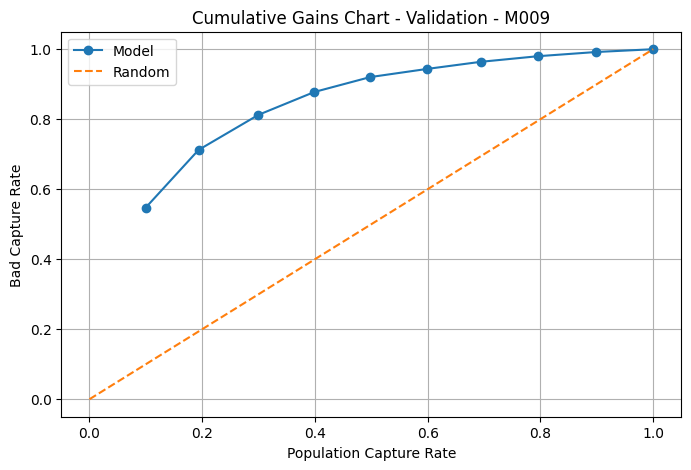

In [48]:
# Lift Chart - Validation

plt.figure(figsize=(8, 5))
plt.plot(
    val_gains["population_capture_rate"],
    val_gains["cum_bad_capture_rate"],
    marker="o",
    label="Model"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.title(f"Cumulative Gains Chart - Validation - {champion_model_number}")
plt.xlabel("Population Capture Rate")
plt.ylabel("Bad Capture Rate")
plt.legend()
plt.grid(True)
plt.show()

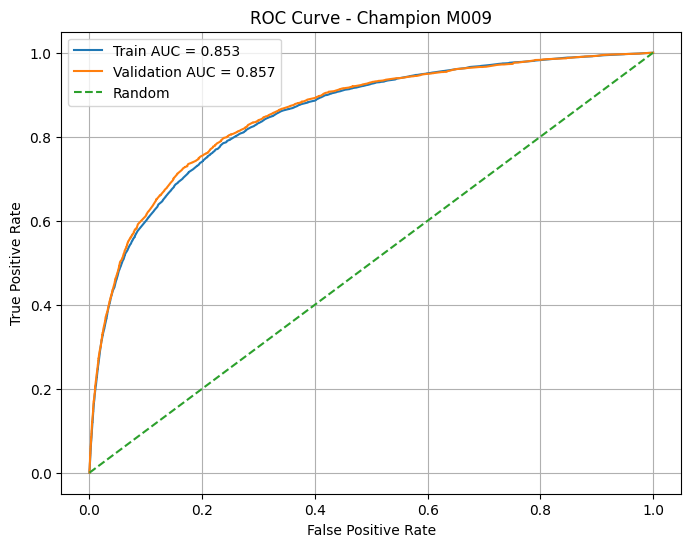

In [47]:
# ROC Curve

fpr_train, tpr_train, _ = roc_curve(y_train, p_train_champ)
fpr_val, tpr_val, _ = roc_curve(y_val, p_val_champ)

train_auc = roc_auc_score(y_train, p_train_champ)
val_auc = roc_auc_score(y_val, p_val_champ)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {train_auc:.3f}")
plt.plot(fpr_val, tpr_val, label=f"Validation AUC = {val_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.title(f"ROC Curve - Champion {champion_model_number}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


In [49]:
# Full diagnostics package for champion model to be exported to Excel

champion_diagnostics_package = {
    "metadata": pd.DataFrame({
        "field": list(champion["metadata"].keys()),
        "value": list(champion["metadata"].values())
    }),
    "coefficients": champion["coefficients"],
    "diagnostics": champion["diagnostics"],
    "vif": champion["vif"],
    "validation_predicted_vs_actual": validation_pva_summary,
    "train_gains_lift": train_gains,
    "validation_gains_lift": val_gains
}

champion_excel_path = OUTPUT_DIR / f"{champion_model_number}_champion_diagnostics.xlsx"

with pd.ExcelWriter(champion_excel_path, engine="openpyxl") as writer:
    for sheet_name, table in champion_diagnostics_package.items():
        table.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved:", champion_excel_path)

Saved: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/M009_champion_diagnostics.xlsx


In [13]:
save_model_artifact(
    model_registry=model_registry,
    model_id="M009",
    model_dir=MODEL_DIR,
    config_dir=CONFIG_DIR
)

Saved model: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/saved_models/M009.joblib
Saved config: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/model_configs/M009_config.json
